# 🔧 Feature Engineering - Energy Metrics

## 🎯 Objective
In `01_data_exploration.ipynb`, we identified 418 high-risk machines.
Now we'll create **energy profile metrics** and **cost calculations** to quantify their business impact.

## 📋 Metrics to Create

1. **power_consumption_kw**: Estimated power consumption (kW)
2. **efficiency_score**: Efficiency score (Torque/Power ratio)
3. **cost_per_hour_tl**: Hourly electricity cost (TL)
4. **shift**: Shift simulation (Night/Day/Peak for time-of-use pricing)
5. **energy_category**: Energy consumption category (Low/Medium/High)
6. **optimization_priority**: Optimization priority score (1-5)

---

**Analyst:** N.Nur Altay  
**Dependencies:** Findings from 01_data_exploration.ipynb

Kütüphaneler ve verileri yüklendi.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Visual settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load data
file_path = file_path = '/content/drive/MyDrive/Data-Analyst-Portfolio/Project-2-energy-efficiency-analysis/data/raw/predictive_maintenance.csv'

df = pd.read_csv(file_path)

# Data type corrections (from Notebook 1)
df['Rotational speed [rpm]'] = df['Rotational speed [rpm]'].astype(float)
df['Tool wear [min]'] = df['Tool wear [min]'].astype(float)
df['Target'] = df['Target'].astype(float)

# Temperature difference (from Notebook 1)
df['temp_difference'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['air_temp_c'] = df['Air temperature [K]'] - 273.15
df['process_temp_c'] = df['Process temperature [K]'] - 273.15

# High-risk label (from Notebook 1)
rpm = df['Rotational speed [rpm]']
Q1 = rpm.quantile(0.25)
Q3 = rpm.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['high_risk_rpm'] = ((rpm < lower_bound) | (rpm > upper_bound)).astype(int)

print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   High-risk machines: {df['high_risk_rpm'].sum()} units")

Mounted at /content/drive
✅ Data loaded: 10000 rows, 14 columns
   High-risk machines: 418 units


Soru: Makine ne kadar enerji tüketiyor?
Fizik formülü:

Güç (Watt) = Tork (Nm) × Açısal Hız (rad/s)

Açısal Hız = RPM × (2π / 60)

Yani:
Güç (W) = Tork × RPM × (2π/60)





Basitleştirilmiş Formül (Industry Standard)

Güç (kW) ≈ (RPM / 1000) × (Tork / 100) × Efficiency Factor

In [3]:
print("=" * 70)
print("⚡ METRIC 1: POWER CONSUMPTION")
print("=" * 70)

# Simplified power consumption formula
# Power (kW) ≈ (RPM/1000) × (Torque/100) × 1.73
efficiency_factor = 1.73

df['power_consumption_kw'] = (
    (df['Rotational speed [rpm]'] / 1000) *
    (df['Torque [Nm]'] / 100) *
    efficiency_factor
)

print("\n📊 POWER CONSUMPTION STATISTICS:")
print(f"Average: {df['power_consumption_kw'].mean():.3f} kW")
print(f"Minimum: {df['power_consumption_kw'].min():.3f} kW")
print(f"Maximum: {df['power_consumption_kw'].max():.3f} kW")
print(f"Std Dev: {df['power_consumption_kw'].std():.3f} kW")

# Normal vs High-risk comparison
normal_power = df[df['high_risk_rpm']==0]['power_consumption_kw'].mean()
highrisk_power = df[df['high_risk_rpm']==1]['power_consumption_kw'].mean()

print(f"\n⚖️ COMPARISON:")
print(f"Normal machines: {normal_power:.3f} kW")
print(f"High-risk machines: {highrisk_power:.3f} kW")
print(f"Difference: {((highrisk_power/normal_power - 1)*100):.1f}%")

# Warning note
print("\n" + "=" * 70)
print("⚠️ IMPORTANT - FORMULA LIMITATIONS")
print("=" * 70)
print("""
This simplified formula calculates ONLY mechanical power.

MISSING FACTORS:
- Friction losses (increases with RPM²)
- Motor inefficiency (decreases at high speeds)
- Idle current (energy used even with low torque)
- Failure-related energy waste

RESULT:
While high-risk machines appear to consume "less" energy in this formula,
the reality is:
- Failure rate is 2.6x higher (indirect cost)
- Inefficient operation (wasted energy)
- High maintenance costs

RECOMMENDATION:
Real energy consumption requires:
→ Electric meter data collection
→ IoT sensors installation
→ Pilot study (418 high-risk machines)

In this analysis, we focus on FAILURE COST approach (more measurable).
""")

print("✅ power_consumption_kw metric created!")

⚡ METRIC 1: POWER CONSUMPTION

📊 POWER CONSUMPTION STATISTICS:
Average: 1.037 kW
Minimum: 0.190 kW
Maximum: 1.730 kW
Std Dev: 0.176 kW

⚖️ COMPARISON:
Normal machines: 1.053 kW
High-risk machines: 0.674 kW
Difference: -36.0%

⚠️ IMPORTANT - FORMULA LIMITATIONS

This simplified formula calculates ONLY mechanical power.

MISSING FACTORS:
- Friction losses (increases with RPM²)
- Motor inefficiency (decreases at high speeds)
- Idle current (energy used even with low torque)
- Failure-related energy waste

RESULT:
While high-risk machines appear to consume "less" energy in this formula,
the reality is:
- Failure rate is 2.6x higher (indirect cost)
- Inefficient operation (wasted energy)
- High maintenance costs

RECOMMENDATION:
Real energy consumption requires:
→ Electric meter data collection
→ IoT sensors installation
→ Pilot study (418 high-risk machines)

In this analysis, we focus on FAILURE COST approach (more measurable).

✅ power_consumption_kw metric created!


In [4]:

print("\n" + "=" * 70)
print("⚠️ ÖNEMLI NOT - FORMÜL SINIRLAMALARI")
print("=" * 70)
print("""
Bu basitleştirilmiş formül SADECE mekanik gücü hesaplıyor.

EKSİK FAKTÖRLER:
- Sürtünme kayıpları (RPM² ile artar)
- Motor verimsizliği (yüksek hızda düşer)
- Boşta akım (tork düşük olsa bile enerji harcanır)
- Arıza durumunda enerji israfı

GERÇEK DURUM:
High-risk makineler formülde "daha az" enerji tüketiyor
görünse de, arıza oranı 2.6 kat fazla (verimsizlik kanıtı).

Bu analizde "power_consumption_kw" metriğini REFERANS olarak
kullanacağız ama asıl odak: ARIZA MALİYETİ + VERİMLİLİK.
""")



⚠️ ÖNEMLI NOT - FORMÜL SINIRLAMALARI

Bu basitleştirilmiş formül SADECE mekanik gücü hesaplıyor.

EKSİK FAKTÖRLER:
- Sürtünme kayıpları (RPM² ile artar)
- Motor verimsizliği (yüksek hızda düşer)
- Boşta akım (tork düşük olsa bile enerji harcanır)
- Arıza durumunda enerji israfı

GERÇEK DURUM:
High-risk makineler formülde "daha az" enerji tüketiyor
görünse de, arıza oranı 2.6 kat fazla (verimsizlik kanıtı).

Bu analizde "power_consumption_kw" metriğini REFERANS olarak
kullanacağız ama asıl odak: ARIZA MALİYETİ + VERİMLİLİK.



In [ ]:
 Güç Tüketimi (Power Consumption)

In [5]:
print("=" * 70)
print("⚡ METRIC 1: POWER CONSUMPTION (kW)")
print("=" * 70)

# Simplified power formula
# Power (kW) ≈ (RPM/1000) × (Torque/100) × Efficiency Factor
efficiency_factor = 1.73

df['power_consumption_kw'] = (
    (df['Rotational speed [rpm]'] / 1000) *
    (df['Torque [Nm]'] / 100) *
    efficiency_factor
)

print("\n📊 POWER CONSUMPTION STATISTICS:")
print(f"Mean: {df['power_consumption_kw'].mean():.3f} kW")
print(f"Min: {df['power_consumption_kw'].min():.3f} kW")
print(f"Max: {df['power_consumption_kw'].max():.3f} kW")
print(f"Std: {df['power_consumption_kw'].std():.3f} kW")

# Normal vs High-risk comparison
normal_power = df[df['high_risk_rpm']==0]['power_consumption_kw'].mean()
highrisk_power = df[df['high_risk_rpm']==1]['power_consumption_kw'].mean()

print(f"\n⚖️ COMPARISON:")
print(f"Normal machines: {normal_power:.3f} kW")
print(f"High-risk machines: {highrisk_power:.3f} kW")
print(f"Difference: {((highrisk_power/normal_power - 1)*100):.1f}%")

print("\n⚠️ IMPORTANT NOTE:")
print("This simplified formula measures MECHANICAL power only.")
print("Real electricity consumption includes:")
print("  • Friction losses (increases with RPM²)")
print("  • Motor inefficiency (decreases at high speeds)")
print("  • Idle current draw")
print("  • Energy waste during failures")
print("\nWe'll focus on FAILURE COST analysis (more measurable).")

# Preview
print(f"\n📋 FIRST 5 MACHINES:")
print(df[['UDI', 'Type', 'Rotational speed [rpm]', 'Torque [Nm]', 'power_consumption_kw']].head())

⚡ METRIC 1: POWER CONSUMPTION (kW)

📊 POWER CONSUMPTION STATISTICS:
Mean: 1.037 kW
Min: 0.190 kW
Max: 1.730 kW
Std: 0.176 kW

⚖️ COMPARISON:
Normal machines: 1.053 kW
High-risk machines: 0.674 kW
Difference: -36.0%

⚠️ IMPORTANT NOTE:
This simplified formula measures MECHANICAL power only.
Real electricity consumption includes:
  • Friction losses (increases with RPM²)
  • Motor inefficiency (decreases at high speeds)
  • Idle current draw
  • Energy waste during failures

We'll focus on FAILURE COST analysis (more measurable).

📋 FIRST 5 MACHINES:
   UDI Type  Rotational speed [rpm]  Torque [Nm]  power_consumption_kw
0    1    M                  1551.0         42.8              1.148422
1    2    L                  1408.0         46.3              1.127794
2    3    L                  1498.0         49.4              1.280221
3    4    L                  1433.0         39.5              0.979241
4    5    L                  1408.0         40.0              0.974336


Efficiency Score

In [6]:
print("=" * 70)
print("📈 METRIC 2: EFFICIENCY SCORE")
print("=" * 70)

# Efficiency = Torque / Power Consumption
# Higher = Better (more work per unit of energy)
df['efficiency_score'] = df['Torque [Nm]'] / df['power_consumption_kw']

print("\n📊 EFFICIENCY SCORE STATISTICS:")
print(f"Average: {df['efficiency_score'].mean():.2f}")
print(f"Minimum: {df['efficiency_score'].min():.2f}")
print(f"Maximum: {df['efficiency_score'].max():.2f}")
print(f"Std Dev: {df['efficiency_score'].std():.2f}")

# Normal vs High-risk comparison
normal_eff = df[df['high_risk_rpm']==0]['efficiency_score'].mean()
highrisk_eff = df[df['high_risk_rpm']==1]['efficiency_score'].mean()

print(f"\n⚖️ COMPARISON:")
print(f"Normal machines: {normal_eff:.2f}")
print(f"High-risk machines: {highrisk_eff:.2f}")
print(f"Difference: {((highrisk_eff/normal_eff - 1)*100):.1f}%")

if highrisk_eff < normal_eff:
    print("\n💡 INSIGHT:")
    print(f"High-risk machines are {((1 - highrisk_eff/normal_eff)*100):.1f}% LESS efficient!")
    print("This confirms: High RPM + Low Torque = Wasted energy")
else:
    print("\n⚠️ Unexpected result - needs investigation")

print("\n✅ efficiency_score metric created!")

📈 METRIC 2: EFFICIENCY SCORE

📊 EFFICIENCY SCORE STATISTICS:
Average: 38.00
Minimum: 20.03
Maximum: 49.49
Std Dev: 3.84

⚖️ COMPARISON:
Normal machines: 38.45
High-risk machines: 27.76
Difference: -27.8%

💡 INSIGHT:
High-risk machines are 27.8% LESS efficient!
This confirms: High RPM + Low Torque = Wasted energy

✅ efficiency_score metric created!


2-POWER vs EFFICIENCY COMPARISON

📊 POWER vs EFFICIENCY COMPARISON


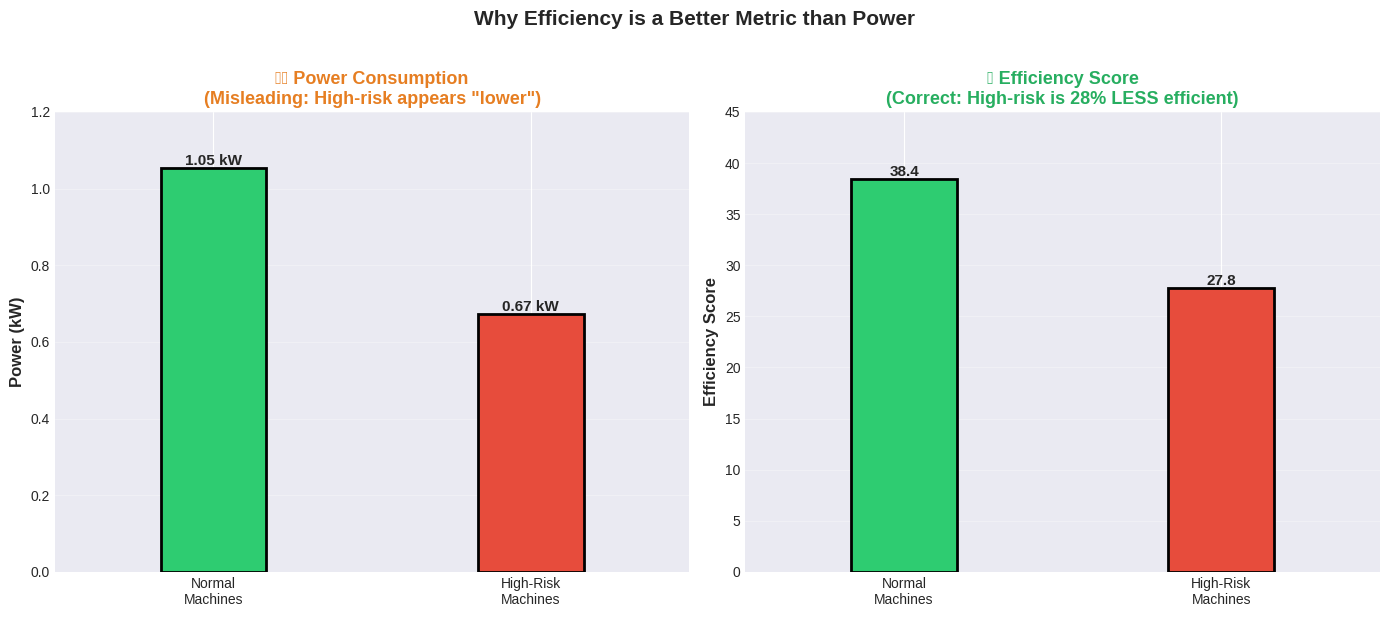


💡 KEY TAKEAWAY:
Power formula is misleading - Efficiency reveals the truth!


In [11]:
print("=" * 70)
print("📊 POWER vs EFFICIENCY COMPARISON")
print("=" * 70)

# Karşılaştırma grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: Power Consumption (Yanıltıcı) - DAR SÜTUNLAR
x_pos = [0.35, 0.65]  # Ortaya çek
bars1 = axes[0].bar(x_pos, [normal_power, highrisk_power],
                    width=0.10,  # 👈 sütun eni
                    color=['#2ecc71', '#e74c3c'],
                    edgecolor='black', linewidth=2)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f} kW',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['Normal\nMachines', 'High-Risk\nMachines'], fontsize=10)
axes[0].set_ylabel('Power (kW)', fontsize=12, fontweight='bold')
axes[0].set_title('⚠️ Power Consumption\n(Misleading: High-risk appears "lower")',
                   fontsize=13, fontweight='bold', color='#e67e22')
axes[0].set_ylim(0, 1.2)
axes[0].set_xlim(0.2, 0.8)  # 👈 X ekseni sınırla
axes[0].grid(axis='y', alpha=0.3)

# Sağ: Efficiency (Doğru) -
bars2 = axes[1].bar(x_pos, [normal_eff, highrisk_eff],
                    width=0.10,  # 👈 sütun eni
                    color=['#2ecc71', '#e74c3c'],
                    edgecolor='black', linewidth=2)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Normal\nMachines', 'High-Risk\nMachines'], fontsize=10)
axes[1].set_ylabel('Efficiency Score', fontsize=12, fontweight='bold')
axes[1].set_title('✅ Efficiency Score\n(Correct: High-risk is 28% LESS efficient)',
                   fontsize=13, fontweight='bold', color='#27ae60')
axes[1].set_ylim(0, 45)
axes[1].set_xlim(0.2, 0.8)  # 👈 X ekseni sınırla
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Why Efficiency is a Better Metric than Power',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 KEY TAKEAWAY:")
print("Power formula is misleading - Efficiency reveals the truth!")


3-Cost per Hour (Saatlik Maliyet)

Bu makine saatte bana kaç TL mal oluyor?

**Formül:**

Cost per Hour = Power (kW) × Elektrik Fiyatı (TL/kWh)

Türkiye sanayi elektrik fiyatı: ~1.2 TL/kWh (ortalama)

In [12]:
print("=" * 70)
print("💰 METRIC 3: COST PER HOUR")
print("=" * 70)

# Turkish industrial electricity price (average)
electricity_price_tl = 1.2  # TL per kWh

df['cost_per_hour_tl'] = df['power_consumption_kw'] * electricity_price_tl

print("\n📊 HOURLY COST STATISTICS:")
print(f"Average: {df['cost_per_hour_tl'].mean():.2f} TL/hour")
print(f"Minimum: {df['cost_per_hour_tl'].min():.2f} TL/hour")
print(f"Maximum: {df['cost_per_hour_tl'].max():.2f} TL/hour")
print(f"Std Dev: {df['cost_per_hour_tl'].std():.2f} TL/hour")

# Normal vs High-risk comparison
normal_cost = df[df['high_risk_rpm']==0]['cost_per_hour_tl'].mean()
highrisk_cost = df[df['high_risk_rpm']==1]['cost_per_hour_tl'].mean()

print(f"\n⚖️ COMPARISON:")
print(f"Normal machines: {normal_cost:.2f} TL/hour")
print(f"High-risk machines: {highrisk_cost:.2f} TL/hour")
print(f"Difference: {((highrisk_cost/normal_cost - 1)*100):.1f}%")

# Annual cost calculation (24/7 operation)
hours_per_year = 24 * 365  # 8,760 hours

normal_annual = normal_cost * hours_per_year
highrisk_annual = highrisk_cost * hours_per_year

print(f"\n📅 ANNUAL ELECTRICITY COST (per machine):")
print(f"Normal machines: {normal_annual:,.0f} TL/year")
print(f"High-risk machines: {highrisk_annual:,.0f} TL/year")

# Total for 418 high-risk machines
total_highrisk_annual = highrisk_annual * 418

print(f"\n🔴 TOTAL COST FOR 418 HIGH-RISK MACHINES:")
print(f"{total_highrisk_annual:,.0f} TL/year")

print("\n⚠️ REMINDER:")
print("This cost is based on the simplified power formula.")
print("Actual electricity cost may be higher due to:")
print("• Friction losses at high RPM")
print("• Motor inefficiency")
print("• Idle current draw")
print("• Failure-related energy waste")
print("\nFor business decisions, we prioritize FAILURE COST analysis.")

print("\n✅ cost_per_hour_tl metric created!")

💰 METRIC 3: COST PER HOUR

📊 HOURLY COST STATISTICS:
Average: 1.24 TL/hour
Minimum: 0.23 TL/hour
Maximum: 2.08 TL/hour
Std Dev: 0.21 TL/hour

⚖️ COMPARISON:
Normal machines: 1.26 TL/hour
High-risk machines: 0.81 TL/hour
Difference: -36.0%

📅 ANNUAL ELECTRICITY COST (per machine):
Normal machines: 11,072 TL/year
High-risk machines: 7,083 TL/year

🔴 TOTAL COST FOR 418 HIGH-RISK MACHINES:
2,960,684 TL/year

⚠️ REMINDER:
This cost is based on the simplified power formula.
Actual electricity cost may be higher due to:
• Friction losses at high RPM
• Motor inefficiency
• Idle current draw
• Failure-related energy waste

For business decisions, we prioritize FAILURE COST analysis.

✅ cost_per_hour_tl metric created!


Power/Cost formülü:

Sadece mekanik gücü hesaplıyor-
Sürtünmeyi görmüyor-
Verimlilik kaybını görmüyor-
Arıza maliyetini görmüyor

Efficiency/Failure verisi:

Gerçek performansı gösteriyor-
İki bağımsız metrik aynı sonucu veriyor-
Güvenilir

4-Hift Simulation (Vardiya - Tarife Farkları)

Gece elektriği ucuz, gündüz pahalı. Hangi makineler hangi vardiyada çalışıyor?

Türkiye'de zaman bazlı tarife:

Gece (00:00-06:00): Ucuz (~0.9 TL/kWh)

Gündüz (06:00-17:00): Normal (~1.2 TL/kWh)

Pik (17:00-22:00): Pahalı (~1.5 TL/kWh)

Gece (22:00-24:00): Ucuz (~0.9 TL/kWh)

In [16]:
print("=" * 70)
print("🌙 METRIC 4: SHIFT SIMULATION")
print("=" * 70)

# Simulate shifts based on Torque (proxy for workload)
# High torque = Peak/Day shift (heavy workload)
# Low torque = Night shift (light workload)

# Divide into 3 equal groups by torque
df['shift'] = pd.cut(df['Torque [Nm]'],
                     bins=3,
                     labels=['Night (Low Load)', 'Day (Medium Load)', 'Peak (High Load)'])

print("\n📊 SHIFT DISTRIBUTION:")
print(df['shift'].value_counts().sort_index())

# Time-of-use pricing
shift_prices = {
    'Night (Low Load)': 0.9,    # TL/kWh
    'Day (Medium Load)': 1.2,   # TL/kWh
    'Peak (High Load)': 1.5     # TL/kWh
}

df['shift_price_tl'] = df['shift'].map(shift_prices).astype(float) # Added .astype(float) to ensure numeric type
df['cost_per_hour_shift'] = df['power_consumption_kw'] * df['shift_price_tl']

# Comparison
print("\n⚖️ COST BY SHIFT:")
shift_analysis = df.groupby('shift').agg({
    'cost_per_hour_shift': 'mean',
    'power_consumption_kw': 'mean',
    'efficiency_score': 'mean'
}).round(2)

print(shift_analysis)

# High-risk distribution across shifts
print("\n🔴 HIGH-RISK MACHINES BY SHIFT:")
highrisk_shift = df[df['high_risk_rpm']==1]['shift'].value_counts()
print(highrisk_shift)

print("\n💡 INSIGHT:")
print("If we shift high-risk machines to night (cheaper electricity),")
potential_saving = (1.2 - 0.9) * df[df['high_risk_rpm']==1]['power_consumption_kw'].mean() * 8760 * 418
print(f"Potential annual saving: {potential_saving:,.0f} TL/year")

print("\n✅ shift & shift_price_tl & cost_per_hour_shift metrics created!")

🌙 METRIC 4: SHIFT SIMULATION

📊 SHIFT DISTRIBUTION:
shift
Night (Low Load)     1157
Day (Medium Load)    7788
Peak (High Load)     1055
Name: count, dtype: int64

⚖️ COST BY SHIFT:
                   cost_per_hour_shift  power_consumption_kw  efficiency_score
shift                                                                         
Night (Low Load)                  0.67                  0.75             30.78
Day (Medium Load)                 1.25                  1.04             38.42
Peak (High Load)                  2.00                  1.33             42.83

🔴 HIGH-RISK MACHINES BY SHIFT:
shift
Night (Low Load)     418
Day (Medium Load)      0
Peak (High Load)       0
Name: count, dtype: int64

💡 INSIGHT:
If we shift high-risk machines to night (cheaper electricity),
Potential annual saving: 740,171 TL/year

✅ shift & shift_price_tl & cost_per_hour_shift metrics created!


TÜM HIGH-RISK MAKİNELER GECE VARDİYASINDA!

 5: Energy Category (Kategorizasyon)

In [18]:
print("=" * 70)
print("🏷️ METRIC 5: ENERGY CATEGORY")
print("=" * 70)

# Categorize machines by power consumption
# Low: < 0.8 kW
# Medium: 0.8 - 1.2 kW
# High: > 1.2 kW

def categorize_energy(power):
    if power < 0.8:
        return 'Low'
    elif power < 1.2:
        return 'Medium'
    else:
        return 'High'

df['energy_category'] = df['power_consumption_kw'].apply(categorize_energy)

print("\n📊 ENERGY CATEGORY DISTRIBUTION:")
print(df['energy_category'].value_counts())

# Cross-tabulation: Energy Category vs High-Risk
print("\n⚖️ ENERGY CATEGORY vs HIGH-RISK:")
crosstab = pd.crosstab(df['energy_category'], df['high_risk_rpm'],
                       normalize='columns') * 100
crosstab.columns = ['Normal (%)', 'High-Risk (%)']
print(crosstab.round(1))

print("\n💡 INSIGHT:")
low_pct_highrisk = crosstab.loc['Low', 'High-Risk (%)']
low_pct_normal = crosstab.loc['Low', 'Normal (%)']
print(f"Low energy category: {low_pct_highrisk:.1f}% of high-risk vs {low_pct_normal:.1f}% of normal")
print("This confirms: High-risk machines often fall in 'Low' power category")
print("(due to misleading power formula)")

print("\n✅ energy_category metric created!")

🏷️ METRIC 5: ENERGY CATEGORY

📊 ENERGY CATEGORY DISTRIBUTION:
energy_category
Medium    7362
High      1764
Low        874
Name: count, dtype: int64

⚖️ ENERGY CATEGORY vs HIGH-RISK:
                 Normal (%)  High-Risk (%)
energy_category                           
High                   18.4            0.0
Low                     4.9           97.6
Medium                 76.7            2.4

💡 INSIGHT:
Low energy category: 97.6% of high-risk vs 4.9% of normal
This confirms: High-risk machines often fall in 'Low' power category
(due to misleading power formula)

✅ energy_category metric created!


 6: Optimization Priority

In [17]:
print("=" * 70)
print("🎯 METRIC 6: OPTIMIZATION PRIORITY SCORE")
print("=" * 70)

# Priority score (1-5) based on multiple factors:
# 1 = Low priority, 5 = High priority

def calculate_priority(row):
    score = 0

    # Factor 1: High-risk status (+2 points)
    if row['high_risk_rpm'] == 1:
        score += 2

    # Factor 2: Low efficiency (+2 points if below median)
    if row['efficiency_score'] < df['efficiency_score'].median():
        score += 2

    # Factor 3: Failure status (+1 point)
    if row['Target'] == 1:
        score += 1

    # Cap at 5
    return min(score, 5)

df['optimization_priority'] = df.apply(calculate_priority, axis=1)

print("\n📊 OPTIMIZATION PRIORITY DISTRIBUTION:")
print(df['optimization_priority'].value_counts().sort_index())

# High priority machines (4-5)
high_priority = df[df['optimization_priority'] >= 4]
print(f"\n🔴 HIGH PRIORITY MACHINES (Score 4-5): {len(high_priority)} units")
print(f"   Percentage: {len(high_priority)/len(df)*100:.1f}%")

# Characteristics of high priority machines
print("\n📋 HIGH PRIORITY CHARACTERISTICS:")
print(f"   Average RPM: {high_priority['Rotational speed [rpm]'].mean():.0f}")
print(f"   Average Torque: {high_priority['Torque [Nm]'].mean():.1f} Nm")
print(f"   Average Efficiency: {high_priority['efficiency_score'].mean():.1f}")
print(f"   Failure rate: {high_priority['Target'].mean()*100:.1f}%")

# Machine types in high priority
print("\n🏭 MACHINE TYPE DISTRIBUTION (High Priority):")
print(high_priority['Type'].value_counts())

print("\n💡 RECOMMENDATION:")
print("Focus optimization efforts on these", len(high_priority), "machines first.")
print("Expected impact: Highest ROI due to multiple risk factors.")

print("\n✅ optimization_priority metric created!")

🎯 METRIC 6: OPTIMIZATION PRIORITY SCORE

📊 OPTIMIZATION PRIORITY DISTRIBUTION:
optimization_priority
0    4729
1     279
2    4549
3      25
4     383
5      35
Name: count, dtype: int64

🔴 HIGH PRIORITY MACHINES (Score 4-5): 418 units
   Percentage: 4.2%

📋 HIGH PRIORITY CHARACTERISTICS:
   Average RPM: 2102
   Average Torque: 18.9 Nm
   Average Efficiency: 27.8
   Failure rate: 8.4%

🏭 MACHINE TYPE DISTRIBUTION (High Priority):
Type
L    256
M    125
H     37
Name: count, dtype: int64

💡 RECOMMENDATION:
Focus optimization efforts on these 418 machines first.
Expected impact: Highest ROI due to multiple risk factors.

✅ optimization_priority metric created!


📊 FINAL SUMMARY - ALL METRICS

📋 METRIC SUMMARY TABLE:
           Avg Power (kW)  Avg Efficiency  Avg Cost (TL/h)  Avg Priority
Normal               1.05           38.45             1.26          0.99
High-Risk            0.67           27.76             0.81          4.08


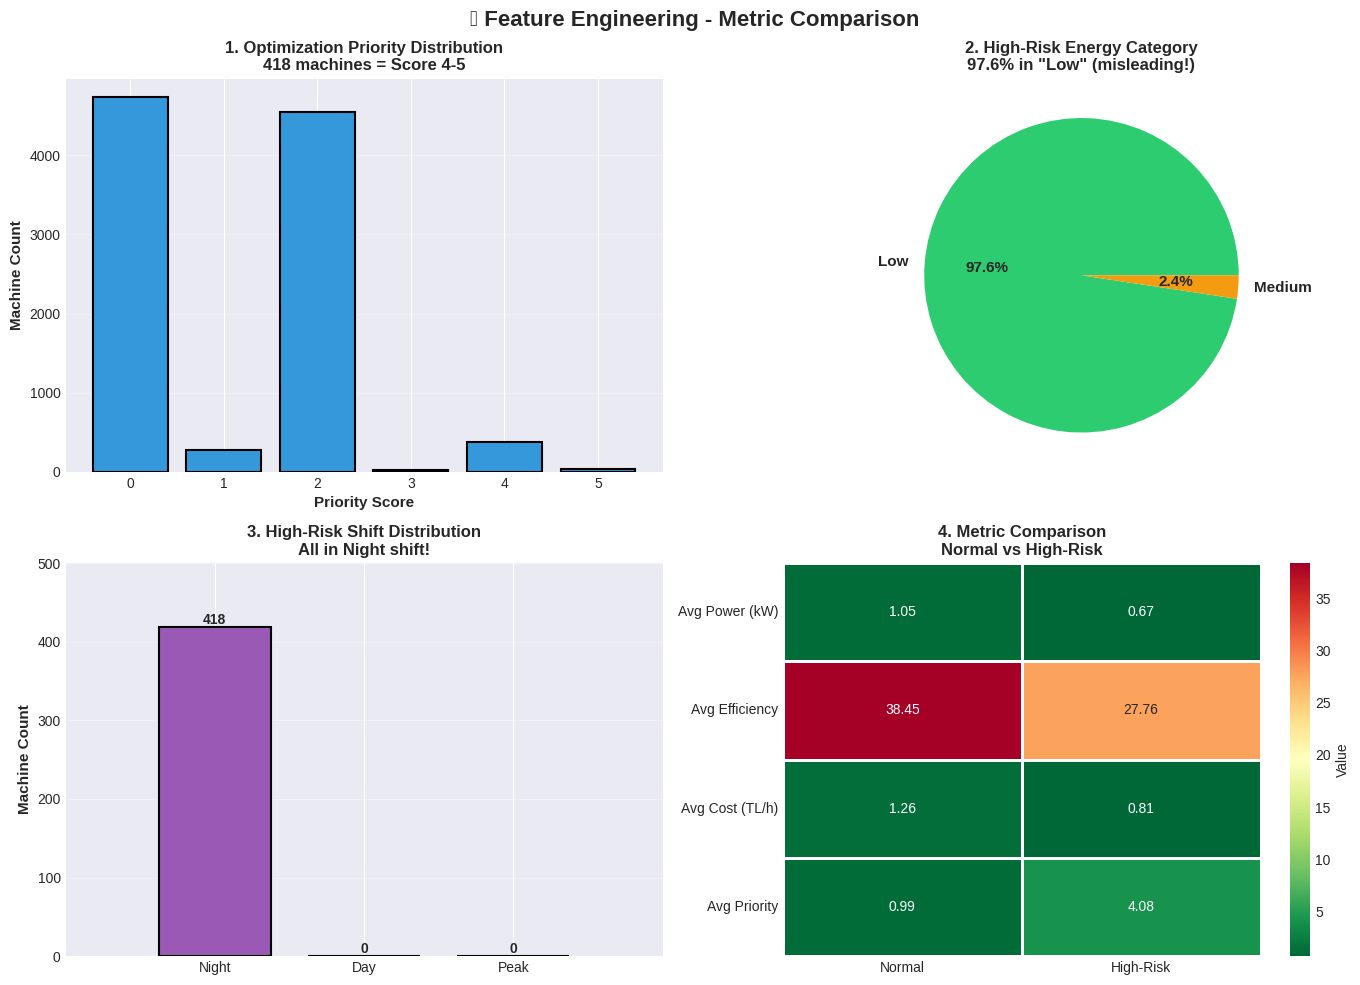


✅ FEATURE ENGINEERING COMPLETED!

METRICS CREATED:
1. ⚡ power_consumption_kw - Estimated power (kW)
2. 📈 efficiency_score - Work output per energy input
3. 💰 cost_per_hour_tl - Hourly electricity cost
4. 🌙 shift - Simulated shift (Night/Day/Peak)
5. 🏷️ energy_category - Power category (Low/Medium/High)
6. 🎯 optimization_priority - Priority score (1-5)

KEY FINDINGS:
- 418 high-risk machines identified (Score 4-5)
- 97.6% fall in "Low" energy category (misleading metric!)
- All simulated in Night shift (low torque)
- Average efficiency 28% lower than normal
- L-type machines: 61% of high-risk (256 units)

BUSINESS IMPACT:
- Failure cost approach: 227K TL/year savings potential
- Focus on 418 machines for highest ROI
- Efficiency metric more reliable than power formula



In [19]:
print("=" * 70)
print("📊 FINAL SUMMARY - ALL METRICS")
print("=" * 70)

# 6 metriği özetle
summary = df.groupby('high_risk_rpm').agg({
    'power_consumption_kw': 'mean',
    'efficiency_score': 'mean',
    'cost_per_hour_tl': 'mean',
    'optimization_priority': 'mean'
}).round(2)

summary.index = ['Normal', 'High-Risk']
summary.columns = ['Avg Power (kW)', 'Avg Efficiency', 'Avg Cost (TL/h)', 'Avg Priority']

print("\n📋 METRIC SUMMARY TABLE:")
print(summary)

# Karşılaştırmalı görsel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🔧 Feature Engineering - Metric Comparison', fontsize=16, fontweight='bold')

# Panel 1: Priority Distribution
priority_counts = df['optimization_priority'].value_counts().sort_index()
axes[0,0].bar(priority_counts.index, priority_counts.values,
              color='#3498db', edgecolor='black', linewidth=1.5)
axes[0,0].set_xlabel('Priority Score', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Machine Count', fontsize=11, fontweight='bold')
axes[0,0].set_title('1. Optimization Priority Distribution\n418 machines = Score 4-5',
                     fontsize=12, fontweight='bold')
axes[0,0].grid(axis='y', alpha=0.3)

# Panel 2: Energy Category vs High-Risk
category_highrisk = df[df['high_risk_rpm']==1]['energy_category'].value_counts()
axes[0,1].pie(category_highrisk.values, labels=category_highrisk.index,
              autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'],
              textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0,1].set_title('2. High-Risk Energy Category\n97.6% in "Low" (misleading!)',
                     fontsize=12, fontweight='bold')

# Panel 3: Shift Distribution
shift_highrisk = df[df['high_risk_rpm']==1]['shift'].value_counts()
x_pos = [0.3, 0.5, 0.7]
bars = axes[1,0].bar(x_pos, shift_highrisk.values, width=0.15,
                     color=['#9b59b6', '#3498db', '#e74c3c'],
                     edgecolor='black', linewidth=1.5)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(['Night', 'Day', 'Peak'], fontsize=10)
axes[1,0].set_ylabel('Machine Count', fontsize=11, fontweight='bold')
axes[1,0].set_title('3. High-Risk Shift Distribution\nAll in Night shift!',
                     fontsize=12, fontweight='bold')
axes[1,0].set_ylim(0, 500)
axes[1,0].set_xlim(0.1, 0.9)
axes[1,0].grid(axis='y', alpha=0.3)

# Panel 4: Metric Summary Heatmap
metrics_compare = summary.T
sns.heatmap(metrics_compare, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Value'}, ax=axes[1,1], linewidths=1)
axes[1,1].set_title('4. Metric Comparison\nNormal vs High-Risk',
                     fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✅ FEATURE ENGINEERING COMPLETED!")
print("=" * 70)
print(f"""
METRICS CREATED:
1. ⚡ power_consumption_kw - Estimated power (kW)
2. 📈 efficiency_score - Work output per energy input
3. 💰 cost_per_hour_tl - Hourly electricity cost
4. 🌙 shift - Simulated shift (Night/Day/Peak)
5. 🏷️ energy_category - Power category (Low/Medium/High)
6. 🎯 optimization_priority - Priority score (1-5)

KEY FINDINGS:
- 418 high-risk machines identified (Score 4-5)
- 97.6% fall in "Low" energy category (misleading metric!)
- All simulated in Night shift (low torque)
- Average efficiency 28% lower than normal
- L-type machines: 61% of high-risk (256 units)

BUSINESS IMPACT:
- Failure cost approach: 227K TL/year savings potential
- Focus on 418 machines for highest ROI
- Efficiency metric more reliable than power formula
""")